# Objective benchmark

One locked cross-user split; model seeds 11/23/37 measure optimization variability, not uncertainty across user splits. Shuffle replicates are averaged within each model seed before mean/SD. The REF checkpoint is reused, not retrained or counted as a new replicate. Primary representation is communicated spikes; pre-reset membrane is secondary. Relative10 is an offline, duration-aware reference, not a guaranteed upper bound. No training or probe fitting is performed by this notebook.

In [7]:
from pathlib import Path
import sys
from IPython.display import display
import pandas as pd

REPO = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "core_benchmark_v1/protocol.py").is_file()), None)
if REPO is None:
    raise FileNotFoundError("Open this notebook inside the WritingRing repository")
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))
from core_benchmark_v1.analysis import results_root, load_manifest, table, plot_native, plot_probe, plot_readout
ROOT = results_root(REPO)
MANIFEST = load_manifest(ROOT)
display(MANIFEST)
display(ROOT)


{'aliases': {'D0': 'O0', 'M0': 'O0', 'R0': 'O0', 'REF': 'O0', 'T0': 'O0'},
 'backbone_runs': 27,
 'completed_runs': 33,
 'expected_runs': 33,
 'identity': '85ccaddc963c4502624f02b11ba420bb5c1ac9037abd2715b11b0f52ca175d99',
 'model_seeds': [11, 23, 37],
 'notes': ['Fixed250 shuffle holds partial/padding bins fixed.',
  'Relative10 is an offline duration-aware reference, not an upper bound.',
  'G_order measures decoder-accessible temporal alignment, not pure information or abstraction.'],
 'probe_rows': 2964,
 'profile': 'production',
 'readout_runs': 6,
 'shuffle_averaging': 'replicates averaged within model seed before seed statistics',
 'status': 'PASS',
 'uncertainty_scope': 'model-seed variability on one locked user split, not cross-split uncertainty'}

PosixPath('/home/zhaolongwei_umass_edu/projects/writingRing/core_benchmark_v1/results/main')

## Native accumulator

O0: L2 WCCE. O1: L2 TSCE. O2/O3: L2 WCCE plus 0.1 L1 WCCE/TSCE. Auxiliary heads are training-only. WCCE uses valid-mean logits; TSCE averages within each sample, then over samples.

,case,block,depth,train_ba_mean,train_ba_std,train_ba_count,val_ba_mean,val_ba_std,val_ba_count,test_ba_mean,test_ba_std,test_ba_count,train_test_gap_mean,train_test_gap_std,train_test_gap_count,display_case
0,O0,01_objective,2,0.929721,0.001226,3,0.537035,0.011834,3,0.579301,0.022283,3,0.350420,0.023508,3,O0
1,O1,01_objective,2,0.893430,0.014081,3,0.501477,0.019685,3,0.537203,0.039219,3,0.356227,0.049071,3,O1
2,O2,01_objective,2,0.927786,0.006663,3,0.553670,0.031043,3,0.572265,0.030337,3,0.355521,0.034200,3,O2
3,O3,01_objective,2,0.934454,0.011371,3,0.548962,0.038464,3,0.573393,0.009686,3,0.361061,0.007384,3,O3


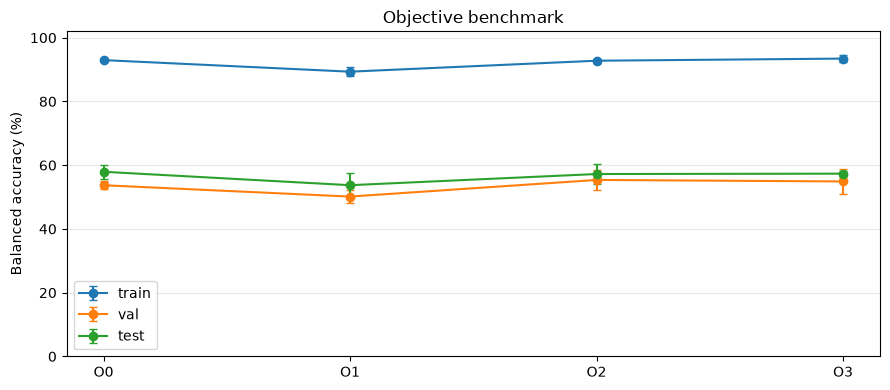

In [2]:
native = table(ROOT, "native_summary", "01_objective")
display(native)
plot_native(native, "Objective benchmark")

## Paired contrasts

Deltas are paired by model seed. Inspect every seed, not only the average.

In [3]:
paired = table(ROOT, "paired_contrasts")
display(paired[paired.block == "01_objective"] if not paired.empty else paired)

,block,contrast,seed,train_delta,val_delta,test_delta
0,01_objective,O1_minus_O0,11,-0.022218,-0.053199,-0.061341
1,01_objective,O1_minus_O0,23,-0.049305,-0.005225,-0.038224
2,01_objective,O1_minus_O0,37,-0.037351,-0.048250,-0.026730
3,01_objective,O2_minus_O0,11,0.003811,0.038660,-0.017298
4,01_objective,O2_minus_O0,23,-0.002509,0.003247,0.028506
5,01_objective,O2_minus_O0,37,-0.007106,0.007997,-0.032316
6,01_objective,O3_minus_O0,11,0.011308,0.041835,0.024477
7,01_objective,O3_minus_O0,23,-0.008627,0.007540,-0.009028
8,01_objective,O3_minus_O0,37,0.011518,-0.013594,-0.033173


## Layer-wise probes

Identical scale-only preprocessing for affine/no-bias probes; C selected using validation users only.

,case,block,layer,state,aggregation,decoder,train_ba_mean,train_ba_std,train_ba_count,val_ba_mean,val_ba_std,val_ba_count,test_ba_mean,test_ba_std,test_ba_count,train_test_gap_mean,train_test_gap_std,train_test_gap_count,display_case
0,O0,01_objective,L1,spike,whole_count,no_bias,0.951595,0.029219,3,0.523856,0.007722,3,0.550810,0.022259,3,0.400785,0.040716,3,O0
1,O0,01_objective,L1,spike,whole_count,affine,0.942231,0.037954,3,0.556560,0.016524,3,0.597463,0.044008,3,0.344768,0.080996,3,O0
2,O0,01_objective,L1,spike,fixed250_ordered,no_bias,0.969751,0.019602,3,0.543370,0.019550,3,0.562823,0.014713,3,0.406928,0.034212,3,O0
3,O0,01_objective,L1,spike,fixed250_ordered,affine,0.982234,0.001048,3,0.520310,0.005468,3,0.561640,0.004196,3,0.420593,0.005227,3,O0
4,O0,01_objective,L1,spike,fixed250_shuffled,no_bias,0.957391,0.019336,3,0.414602,0.019980,3,0.448594,0.023077,3,0.508797,0.007807,3,O0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
155,O3,01_objective,L2,pre_reset,fixed250_shuffled,affine,0.993600,0.007080,3,0.540289,0.013548,3,0.499873,0.021099,3,0.493727,0.018252,3,O3
156,O3,01_objective,L2,pre_reset,relative10_ordered,no_bias,0.981865,0.012254,3,0.698665,0.031199,3,0.654732,0.050515,3,0.327133,0.062628,3,O3
157,O3,01_objective,L2,pre_reset,relative10_ordered,affine,0.986430,0.019330,3,0.654417,0.031638,3,0.652032,0.010974,3,0.334398,0.027837,3,O3
158,O3,01_objective,L2,pre_reset,relative10_shuffled,no_bias,0.977266,0.016319,3,0.517579,0.011141,3,0.484287,0.005005,3,0.492979,0.016758,3,O3


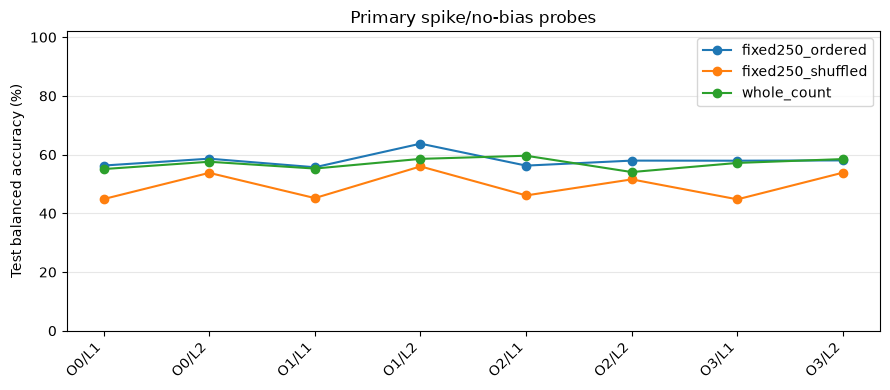

In [4]:
probes = table(ROOT, "probe_summary", "01_objective")
display(probes)
plot_probe(probes, "Primary spike/no-bias probes")

## Temporal and geometry gains

G_resolved = Fixed250 ordered - WholeCount; G_order = ordered - shuffled; G_geometry = affine - no-bias. These measure decoder-accessible organization, not pure mutual information.

In [5]:
display(table(ROOT, "probe_gains_summary", "01_objective"))

,case,block,layer,state,decoder,aggregation,gain,train_delta_mean,train_delta_std,train_delta_count,val_delta_mean,val_delta_std,val_delta_count,test_delta_mean,test_delta_std,test_delta_count,display_case
0,O0,01_objective,L1,spike,no_bias,NaN,G_resolved,0.018156,0.018644,3,0.019515,0.013662,3,0.012013,0.029927,3,O0
1,O0,01_objective,L1,spike,no_bias,NaN,G_order,0.012360,0.024487,3,0.128769,0.026670,3,0.114229,0.023806,3,O0
2,O0,01_objective,L1,spike,no_bias,NaN,G_relative_order,-0.039004,0.031942,3,0.350346,0.028100,3,0.362371,0.015412,3,O0
3,O0,01_objective,L1,spike,affine,NaN,G_resolved,0.040003,0.038425,3,-0.036249,0.014927,3,-0.035823,0.045623,3,O0
4,O0,01_objective,L1,spike,affine,NaN,G_order,-0.005400,0.006480,3,0.127249,0.021198,3,0.112610,0.017555,3,O0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
171,O3,01_objective,L2,pre_reset,affine_minus_no_bias,whole_count,G_geometry,0.008275,0.012992,3,0.002237,0.015995,3,-0.001245,0.033190,3,O3
172,O3,01_objective,L2,pre_reset,affine_minus_no_bias,fixed250_ordered,G_geometry,0.015526,0.017868,3,-0.012388,0.013432,3,-0.009859,0.029483,3,O3
173,O3,01_objective,L2,pre_reset,affine_minus_no_bias,fixed250_shuffled,G_geometry,0.044155,0.029985,3,-0.017560,0.014790,3,-0.021898,0.007094,3,O3
174,O3,01_objective,L2,pre_reset,affine_minus_no_bias,relative10_ordered,G_geometry,0.004566,0.031467,3,-0.044248,0.026509,3,-0.002700,0.058412,3,O3


## Activity and generalization gap

Interpret tau/depth changes together with firing rate, silent neurons, membrane scale and the native/probe train-test gaps.

In [6]:
display(table(ROOT, "activity"))

,case,seed,layer,mean_abs_pre_reset,nonzero_fraction,silent_neuron_fraction,spikes_per_timestep,split,tau_syn_ms
0,O0,11,L1,0.200661,0.052579,0.031250,6.730149,train,"[54.31342963722199, 117.0136826471659, 242.103..."
1,O0,11,L2,0.806898,0.361468,0.000000,46.267875,train,"[54.31342963722199, 117.0136826471659, 242.103..."
2,O0,11,L1,0.182434,0.040745,0.101562,5.215345,val,"[54.31342963722199, 117.0136826471659, 242.103..."
3,O0,11,L2,0.667025,0.326843,0.000000,41.835923,val,"[54.31342963722199, 117.0136826471659, 242.103..."
4,O0,11,L1,0.210443,0.059721,0.070312,7.644301,test,"[54.31342963722199, 117.0136826471659, 242.103..."
...,...,...,...,...,...,...,...,...,...
166,D1,37,L2,0.301852,0.068913,0.000000,8.820823,val,"[54.31342963722199, 117.0136826471659, 242.103..."
167,D1,37,L3,1.119861,0.263806,0.000000,33.767185,val,"[54.31342963722199, 117.0136826471659, 242.103..."
168,D1,37,L1,0.170793,0.021062,0.218750,2.695991,test,"[54.31342963722199, 117.0136826471659, 242.103..."
169,D1,37,L2,0.417334,0.100832,0.000000,12.906478,test,"[54.31342963722199, 117.0136826471659, 242.103..."
